<a href="https://colab.research.google.com/github/anassabbou/AuthenticationSystem/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression**

In [24]:
import pandas as pd # analyser (Excel, CSV, etc.)
import numpy as np #  manipuler les tableaux
import matplotlib.pyplot as plt # Pour Data Visualisation
from sklearn import linear_model # Scikit Learn est une bibliothèse qui offre la majorité des algorithmes de Machine Learning
from sklearn.metrics import root_mean_squared_error, r2_score # Pour évaluer le modèle
# For Data Visualisation
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [25]:
df = pd.read_csv('prix_maisons.csv')

In [26]:
df

,area,price
0,100,1218000
1,120,1440000
2,150,1800000
3,260,2860000
4,320,2880000


Le dataset contient 5 lignes et 2 colonnes


In [27]:
df.shape

(5, 2)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes


In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area,5.0,190.0,95.393920,100.0,120.0,150.0,260.0,320.0
price,5.0,2039600.0,786015.775923,1218000.0,1440000.0,1800000.0,2860000.0,2880000.0


In [30]:
df.isna().sum()

,0
area,0
price,0


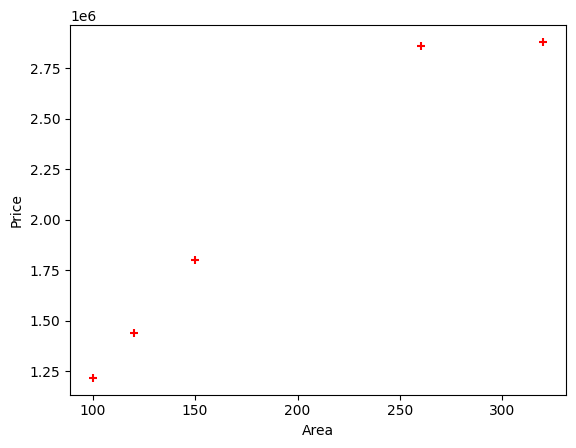

In [31]:
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df['area'], df['price'], color='red', marker="+")

Création du modèle de régression linéaire

---



In [32]:
lr = linear_model.LinearRegression()


Entrainer le modèle :

In [33]:
y = df['price']
X = df.drop(columns=['price'])

In [34]:
lr.fit(X,y)

LinearRegression()

Prédiction :

In [35]:
price =lr.predict([[2300]])
print(price.tolist()[0])

18976407.692307692


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
predicted = lr.predict(X)

In [37]:
print("Predicted => ",predicted)
print ("Target => ", y.tolist())

Predicted =>  [1317176.92307692 1477715.38461538 1718523.07692308 2601484.61538462
 3083100.        ]
Target =>  [1218000, 1440000, 1800000, 2860000, 2880000]


Evaluation du modèle

In [38]:
r2_score(y, predicted)

0.9490237236328821

Expression mathématique du modèle


In [39]:
intercept= lr.intercept_
coef = lr.coef_

In [40]:

price1 = intercept + coef * 1000
price2 = lr.predict([[1000]])
print(price1)
print(price2)

[8541407.69230769]
[8541407.69230769]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


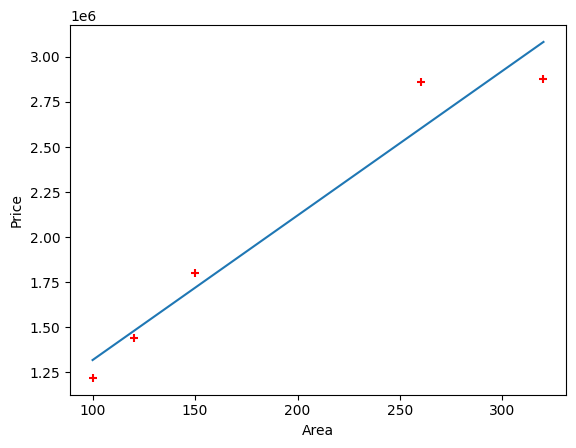

In [41]:

plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df['area'], df['price'], color='red', marker="+")
plt.plot(df['area'], lr.predict(df[['area']]))